# Unit13 Example 05 - 化工案例三：活性碳吸附等溫模式

本 Notebook 以 **16 組實驗數據** 示範如何使用含參數上下限之非線性最小平方法，估計活性碳吸附等溫模式中的三個參數，並計算各參數之 95% 置信區間。

## 學習目標
- 理解活性碳吸附等溫模式 $Q = \dfrac{bC}{1+aC^{\beta}}$ 的物理意義
- 使用 `scipy.optimize.least_squares()` 並設定 `bounds` 參數，進行有界非線性最小平方參數估計
- 使用 `scipy.optimize.curve_fit()` 獲取協方差矩陣 `pcov`，計算各參數之 95% 置信區間
- 比較有界求解策略與直接求解之差異
- 繪製吸附等溫線實驗數據與模式擬合結果比較圖

---
### 0. 環境設定

In [8]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit13_Example_05'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit13'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit13
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Example_05
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Example_05\figs


---
### 1. 載入套件

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import least_squares, curve_fit
from scipy.stats import t as t_dist

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
print(f"  numpy      版本: {np.__version__}")
import scipy
print(f"  scipy      版本: {scipy.__version__}")
import matplotlib
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 實驗數據載入

In [10]:
# ================================================================
# 活性碳吸附等溫模式實驗數據 (呂, 1985)
# C: 溶質水溶液平衡濃度 (mg/L)
# Q: 活性碳吸附量 (mg/g-活性碳)
# ================================================================
C_data = np.array([1.60,  4.52,  6.80,  8.16,  11.5,  12.7,  18.2,  29.0,
                   38.9,  48.9,  57.3,  65.0,  75.0,  85.0,  90.0, 100.0])

Q_data = np.array([170.7, 228.1, 258.0, 283.7, 321.3, 335.4, 378.6, 401.3,
                   422.3, 425.3, 429.0, 430.9, 431.6, 431.7, 431.6, 432.1])

n = len(C_data)
print(f"實驗數據共 {n} 組:\n")
print(f"{'No.':>4}  {'C (mg/L)':>12}  {'Q (mg/g-AC)':>14}")
print("-" * 36)
for i, (c, q) in enumerate(zip(C_data, Q_data), 1):
    print(f"{i:>4}  {c:>12.2f}  {q:>14.1f}")

實驗數據共 16 組:

 No.      C (mg/L)     Q (mg/g-AC)
------------------------------------
   1          1.60           170.7
   2          4.52           228.1
   3          6.80           258.0
   4          8.16           283.7
   5         11.50           321.3
   6         12.70           335.4
   7         18.20           378.6
   8         29.00           401.3
   9         38.90           422.3
  10         48.90           425.3
  11         57.30           429.0
  12         65.00           430.9
  13         75.00           431.6
  14         85.00           431.7
  15         90.00           431.6
  16        100.00           432.1


---
### 3. 有界非線性最小平方參數估計 (`scipy.optimize.least_squares`)

In [11]:
# ================================================================
# 吸附等溫模式定義
# Q_model = b*C / (1 + a*C^beta)
# 參數向量 p = [a, b, beta]
# ================================================================
def adsorption_model(C, a, b, beta):
    """活性碳吸附等溫模式 Q = b*C / (1 + a*C^beta)"""
    return b * C / (1.0 + a * C**beta)

def residual_func(p, C, Q_obs):
    """殘差向量: e_i = Q_obs_i - Q_model_i"""
    a, b, beta = p
    Q_pred = adsorption_model(C, a, b, beta)
    return Q_obs - Q_pred

# ================================================================
# 參數上下限設定
# 0 <= a <= 1,  100 <= b <= 200,  0 <= beta <= 1
# ================================================================
p_lower = [0.0,  100.0, 0.0]
p_upper = [1.0,  200.0, 1.0]
p0 = [(lo + hi) / 2 for lo, hi in zip(p_lower, p_upper)]  # 起始值取中點

print("參數起始猜測值 (各範圍中點):")
print(f"  a    = {p0[0]:.4f}  (範圍: {p_lower[0]:.1f} ~ {p_upper[0]:.1f})")
print(f"  b    = {p0[1]:.4f}  (範圍: {p_lower[1]:.1f} ~ {p_upper[1]:.1f})")
print(f"  beta = {p0[2]:.4f}  (範圍: {p_lower[2]:.1f} ~ {p_upper[2]:.1f})")

# ================================================================
# scipy.optimize.least_squares 有界求解
# ================================================================
result = least_squares(
    residual_func,
    p0,
    args=(C_data, Q_data),
    bounds=(p_lower, p_upper),
    method='trf',      # Trust Region Reflective，支援邊界
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

a_ls, b_ls, beta_ls = result.x
J_ls = np.sum(result.fun**2)

print("\n" + "=" * 60)
print("   有界非線性最小平方參數估計結果 (least_squares)")
print("=" * 60)
print(f"  a    = {a_ls:.4f}")
print(f"  b    = {b_ls:.4f}")
print(f"  beta = {beta_ls:.4f}")
print(f"\n  目標函數值 J (SSE) = {J_ls:.4f}")
print(f"  求解狀態 (success) : {result.success}")
print(f"  求解訊息           : {result.message}")
print("=" * 60)

參數起始猜測值 (各範圍中點):
  a    = 0.5000  (範圍: 0.0 ~ 1.0)
  b    = 150.0000  (範圍: 100.0 ~ 200.0)
  beta = 0.5000  (範圍: 0.0 ~ 1.0)

   有界非線性最小平方參數估計結果 (least_squares)
  a    = 0.3478
  b    = 131.3227
  beta = 0.9575

  目標函數值 J (SSE) = 3118.6391
  求解狀態 (success) : True
  求解訊息           : `ftol` termination condition is satisfied.


---
### 4. 置信區間計算 (`scipy.optimize.curve_fit`)

In [12]:
# ================================================================
# 使用 curve_fit 獲取協方差矩陣，計算 95% 置信區間
# 以 least_squares 求解之參數值作為起始猜測值，提升收斂穩定性
# ================================================================
p_opt, pcov = curve_fit(
    adsorption_model,
    C_data,
    Q_data,
    p0=result.x,                        # 使用 least_squares 結果作起始值
    bounds=(p_lower, p_upper),
    method='trf',
    maxfev=10000,
)

a_cf, b_cf, beta_cf = p_opt

# 計算各參數標準差 (pcov 對角線為方差)
perr = np.sqrt(np.diag(pcov))

# 95% 置信區間: t 分布, 自由度 = n - num_params
dof = n - len(p_opt)
t_val = t_dist.ppf(0.975, df=dof)       # 雙尾 95%，單邊取 97.5%

ci_lower = p_opt - t_val * perr
ci_upper = p_opt + t_val * perr

param_names = ['a', 'b', 'beta']

print("=" * 65)
print("   curve_fit 參數估計值與 95% 置信區間")
print("=" * 65)
print(f"  自由度 (dof) = {dof},  t_0.975 = {t_val:.4f}")
print()
print(f"  {'參數':>6}  {'估計值':>12}  {'標準差':>10}  {'95% CI 下限':>12}  {'95% CI 上限':>12}")
print("-" * 65)
for name, val, err, lo, hi in zip(param_names, p_opt, perr, ci_lower, ci_upper):
    print(f"  {name:>6}  {val:>12.4f}  {err:>10.4f}  {lo:>12.4f}  {hi:>12.4f}")
print("=" * 65)

# 計算各點預測值與誤差
Q_pred = adsorption_model(C_data, *p_opt)
residuals = Q_data - Q_pred
J_cf = np.sum(residuals**2)
MAE = np.mean(np.abs(residuals))

print(f"\n  目標函數值 J (SSE)  = {J_cf:.4f}")
print(f"  平均絕對誤差 (MAE)  = {MAE:.4f} mg/g-活性碳")
print(f"  最大絕對誤差        = {np.max(np.abs(residuals)):.4f} mg/g-活性碳")

   curve_fit 參數估計值與 95% 置信區間
  自由度 (dof) = 13,  t_0.975 = 2.1604

      參數           估計值         標準差     95% CI 下限     95% CI 上限
-----------------------------------------------------------------
       a        0.3478      0.1095        0.1111        0.5844
       b      131.3227     24.4725       78.4530      184.1924
    beta        0.9575      0.0308        0.8909        1.0241

  目標函數值 J (SSE)  = 3118.6391
  平均絕對誤差 (MAE)  = 11.2108 mg/g-活性碳
  最大絕對誤差        = 34.7400 mg/g-活性碳


---
### 5. 各點驗證與誤差分析

In [13]:
print("各量測點驗證結果:\n")
print(f"{'No.':>4}  {'C (mg/L)':>10}  {'Q_exp':>10}  {'Q_model':>10}  {'error':>10}")
print("-" * 52)
for i, (c, q_exp, q_mod, e) in enumerate(zip(C_data, Q_data, Q_pred, residuals), 1):
    sign = '+' if e >= 0 else ''
    print(f"{i:>4}  {c:>10.2f}  {q_exp:>10.1f}  {q_mod:>10.4f}  {sign}{e:>9.4f}")
print("-" * 52)
print(f"\n  誤差平方和 (SSE)   J = {J_cf:.4f}")
print(f"  平均絕對誤差 (MAE)   = {MAE:.4f}")
print(f"  最大絕對誤差         = {np.max(np.abs(residuals)):.4f}")

各量測點驗證結果:

 No.    C (mg/L)       Q_exp     Q_model       error
----------------------------------------------------
   1        1.60       170.7    135.9600  +  34.7400
   2        4.52       228.1    239.8929   -11.7929
   3        6.80       258.0    280.8242   -22.8242
   4        8.16       283.7    298.0201   -14.3201
   5       11.50       321.3    327.9327    -6.6327
   6       12.70       335.4    335.9314    -0.5314
   7       18.20       378.6    362.3778  +  16.2222
   8       29.00       401.3    390.9507  +  10.3493
   9       38.90       422.3    406.0768  +  16.2232
  10       48.90       425.3    416.5560  +   8.7440
  11       57.30       429.0    423.2364  +   5.7636
  12       65.00       430.9    428.2483  +   2.6517
  13       75.00       431.6    433.6448    -2.0448
  14       85.00       431.7    438.1348    -6.4348
  15       90.00       431.6    440.1198    -8.5198
  16      100.00       432.1    443.6791   -11.5791
--------------------------------------------

---
### 6. 吸附等溫線擬合結果圖

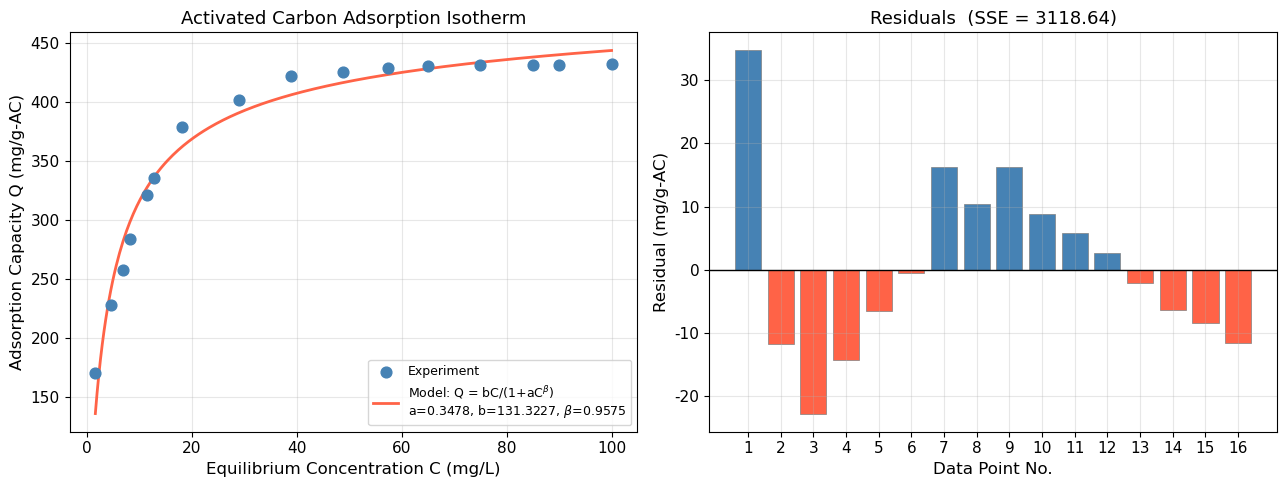

✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Example_05\figs\adsorption_isotherm_fitting.png


In [14]:
# ================================================================
# 繪製雙面板圖：吸附等溫線擬合 + 殘差圖
# ================================================================
C_smooth = np.linspace(C_data.min(), C_data.max(), 300)
Q_smooth = adsorption_model(C_smooth, *p_opt)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- 左圖：吸附等溫線 ---
ax1 = axes[0]
ax1.scatter(C_data, Q_data, color='steelblue', s=60, zorder=5,
            label='Experiment')
ax1.plot(C_smooth, Q_smooth, color='tomato', linewidth=2,
         label=f'Model: Q = bC/(1+aC$^{{\\beta}}$)\n'
               f'a={a_cf:.4f}, b={b_cf:.4f}, $\\beta$={beta_cf:.4f}')
ax1.set_xlabel('Equilibrium Concentration C (mg/L)')
ax1.set_ylabel('Adsorption Capacity Q (mg/g-AC)')
ax1.set_title('Activated Carbon Adsorption Isotherm')
ax1.legend(fontsize=9)

# --- 右圖：殘差圖 ---
ax2 = axes[1]
colors = ['steelblue' if e >= 0 else 'tomato' for e in residuals]
ax2.bar(range(1, n+1), residuals, color=colors, edgecolor='gray', linewidth=0.5)
ax2.axhline(0, color='black', linewidth=1.0)
ax2.set_xlabel('Data Point No.')
ax2.set_ylabel('Residual (mg/g-AC)')
ax2.set_title(f'Residuals  (SSE = {J_cf:.2f})')
ax2.set_xticks(range(1, n+1))

plt.tight_layout()
fig_path = FIG_DIR / 'adsorption_isotherm_fitting.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存: {fig_path}")